Name: Siva Kumar Reddy Surasani
ID: 11702175

# Lab: Comparing Classification Decision Boundaries

This lab reproduces the main idea to compare how different classifiers partition a two-dimensional feature space.

We will study four classifiers:

1. **k-Nearest Neighbors (k-NN)**
2. **Linear Support Vector Machine (Linear SVM)**
3. **Decision Tree**
4. **Gaussian Naive Bayes**

We will apply them to three synthetic datasets:

- Two interleaving moons
- Concentric circles
- A roughly linearly separable dataset

The background color shows each model's predicted class and confidence. The points show the actual samples.

## Learning objectives

By the end of this lab, you should be able to:

- Explain what a **decision boundary** is.
- Compare linear and nonlinear classifiers.
- Identify underfitting and overfitting from a visualization.
- Relate a model's assumptions to the shape of its decision regions.
- Evaluate models using a held-out test set.

In [ ]:
%pip install numpy matplotlib scikit-learn

In [4]:
# Run this cell first.
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import ListedColormap
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Create the datasets

Each dataset has two features so that we can draw the decision boundary directly.

In [6]:
# Dataset 1: nonlinear, moon-shaped classes
X_moons, y_moons = make_moons(
    n_samples=200, noise=0.25, random_state=RANDOM_STATE
)

# Dataset 2: nonlinear, concentric circles
X_circles, y_circles = make_circles(
    n_samples=200, noise=0.15, factor=0.45, random_state=RANDOM_STATE
)

# Dataset 3: approximately linearly separable
X_linear, y_linear = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    class_sep=1.2,
    flip_y=0.08,
    random_state=RANDOM_STATE,
)

datasets = [
    ('Moons', X_moons, y_moons),
    ('Circles', X_circles, y_circles),
    ('Approximately linear', X_linear, y_linear),
]

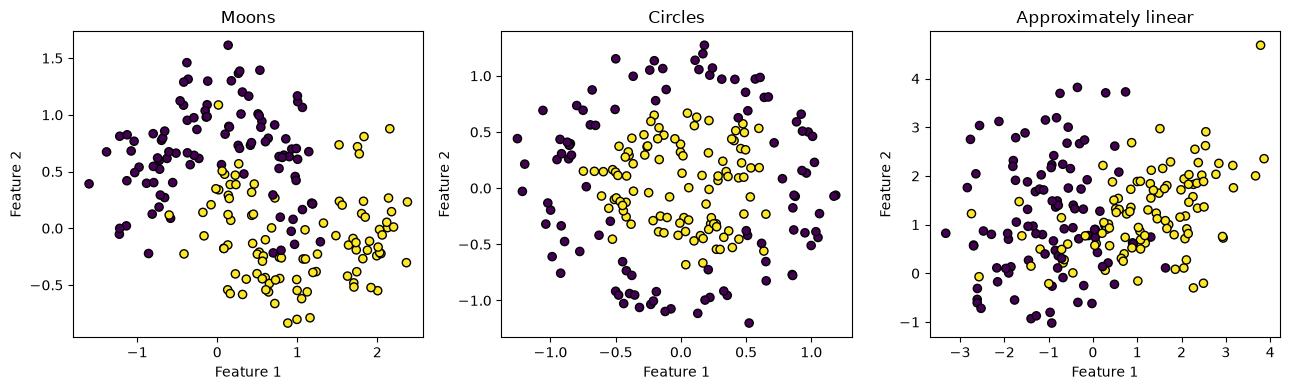

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (name, X, y) in zip(axes, datasets):
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='black', s=35)
    ax.set_title(name)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

### Checkpoint 1

Before training any models, predict which classifier will work best on each dataset.

| Dataset | Your predicted best classifier | Why? |
|---|---|---|
| Moons | KNN | Knn forms a nonlinear boundary based on the distance between the points. It can follow moon shaped data aligned properly with the data. |
| Circles | KNN  | Knn classifier is suitable for forming a non linear boundary of the inner circle and outer circle. Knn will form the inner circle using local neigbhourhood and will form the outer circle with the same principle |
| Approximately linear | Linear SVM | Linear SVM creates a decision boundary with wide margin. This matches the linearly separable data and the wide margin can handle the noise well. |

## 2. Define the classifiers

Standardization is important for distance-based methods and SVMs. We therefore place a `StandardScaler` before k-NN and the SVM.

In [8]:
classifiers = [
    (
        'Nearest Neighbors',
        make_pipeline(
            StandardScaler(),
            KNeighborsClassifier(n_neighbors=7)
        ),
    ),
    (
        'Linear SVM',
        make_pipeline(
            StandardScaler(),
            SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_STATE)
        ),
    ),
    (
        'Decision Tree',
        DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    ),
    (
        'Naive Bayes',
        GaussianNB(),
    ),
]

## 3. Plot the decision boundaries

For every dataset, we split the data into 70% training and 30% testing. The number in the lower-right corner of each model panel is test accuracy.

C:\Users\suras\Documents\csce5218\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\suras\Documents\csce5218\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\suras\Documents\csce5218\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


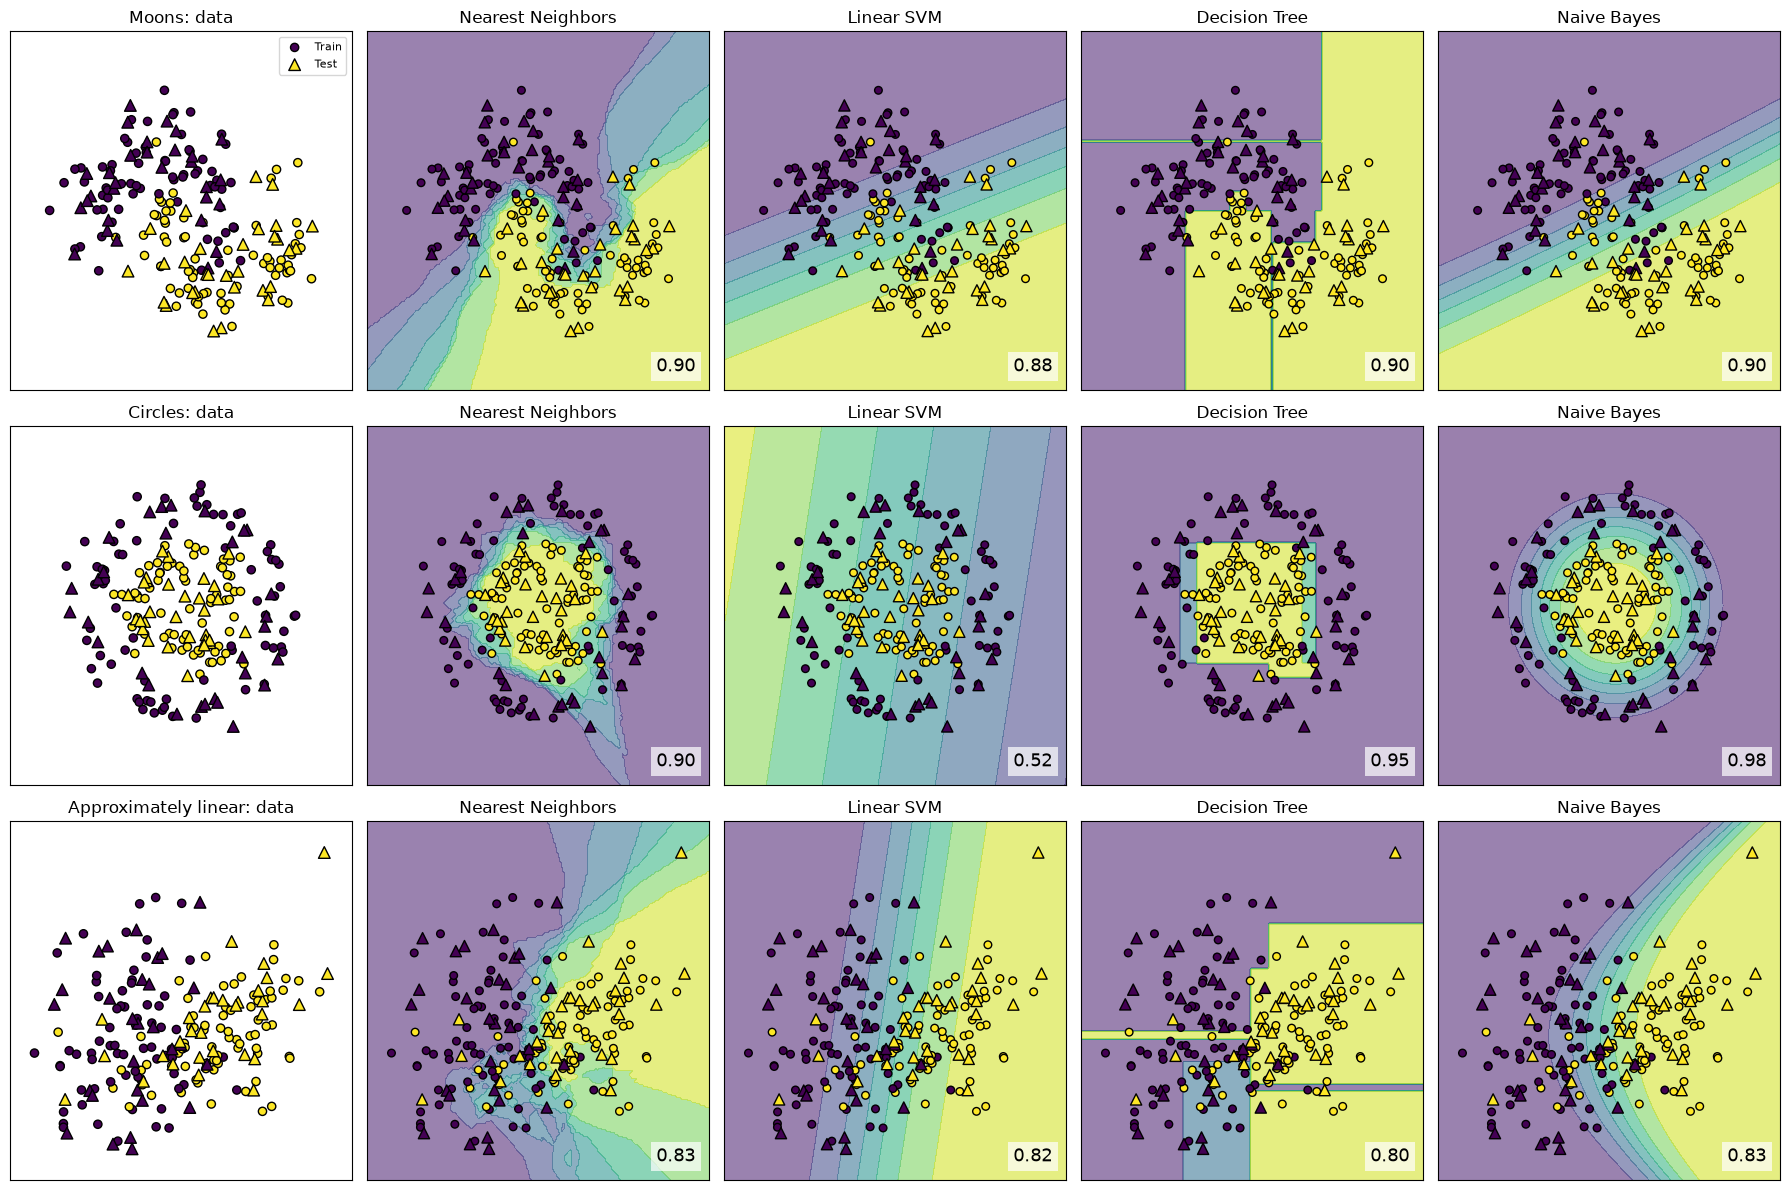

In [9]:
def plot_classifier_comparison(datasets, classifiers):
    n_rows = len(datasets)
    n_cols = len(classifiers) + 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 12))

    for row, (dataset_name, X, y) in enumerate(datasets):
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.30,
            stratify=y,
            random_state=RANDOM_STATE,
        )

        x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
        y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

        # First column: raw data
        ax = axes[row, 0]
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train,
            edgecolors='black', s=35, label='Train'
        )
        ax.scatter(
            X_test[:, 0], X_test[:, 1], c=y_test,
            edgecolors='black', s=70, marker='^', label='Test'
        )
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f'{dataset_name}: data')
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.legend(loc='upper right', fontsize=8)

        for col, (model_name, model) in enumerate(classifiers, start=1):
            ax = axes[row, col]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            score = accuracy_score(y_test, y_pred)

            # probability gives a smooth confidence background
            DecisionBoundaryDisplay.from_estimator(
                model,
                X,
                response_method='predict_proba',
                class_of_interest=1,
                alpha=0.55,
                grid_resolution=250,
                ax=ax,
            )

            ax.scatter(
                X_train[:, 0], X_train[:, 1], c=y_train,
                edgecolors='black', s=30
            )
            ax.scatter(
                X_test[:, 0], X_test[:, 1], c=y_test,
                edgecolors='black', s=65, marker='^'
            )
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_title(model_name)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.text(
                0.96, 0.04, f'{score:.2f}',
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=13,
                bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none'},
            )

    plt.tight_layout()
    plt.show()


plot_classifier_comparison(datasets, classifiers)

## 4. Interpretation guide

### k-Nearest Neighbors

- Predicts according to nearby training samples.
- Can create highly flexible, irregular boundaries.
- A small `k` may overfit; a large `k` may oversmooth.

### Linear SVM

- Produces a straight-line boundary in this two-dimensional setting.
- Works well when classes are approximately linearly separable.
- Cannot naturally represent rings or curved moon shapes with a linear kernel.

### Decision Tree

- Splits one feature at a time.
- Produces rectangular, axis-aligned decision regions.
- Deep trees can memorize training data and overfit.

### Gaussian Naive Bayes

- Models each feature as conditionally independent and Gaussian within each class.
- Often creates smooth, curved decision boundaries.
- Its assumptions can be too restrictive when features are strongly dependent.

## 5. Quantitative comparison

In [11]:
results = []

for dataset_name, X, y in datasets:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
    )

    for model_name, model in classifiers:
        model.fit(X_train, y_train)
        train_acc = model.score(X_train, y_train)
        test_acc = model.score(X_test, y_test)
        results.append((dataset_name, model_name, train_acc, test_acc))

print(f"{'Dataset':<23} {'Classifier':<20} {'Train':>8} {'Test':>8} {'Gap':>8}")
print('-' * 72)
for dataset_name, model_name, train_acc, test_acc in results:
    print(
        f'{dataset_name:<23} {model_name:<20} '
        f'{train_acc:>8.3f} {test_acc:>8.3f} {train_acc-test_acc:>8.3f}'
    )

Dataset                 Classifier              Train     Test      Gap
------------------------------------------------------------------------
Moons                   Nearest Neighbors       0.929    0.900    0.029
Moons                   Linear SVM              0.807    0.883   -0.076
Moons                   Decision Tree           0.979    0.900    0.079
Moons                   Naive Bayes             0.807    0.900   -0.093
Circles                 Nearest Neighbors       0.921    0.900    0.021
Circles                 Linear SVM              0.550    0.517    0.033
Circles                 Decision Tree           0.957    0.950    0.007
Circles                 Naive Bayes             0.936    0.983   -0.048
Approximately linear    Nearest Neighbors       0.864    0.833    0.031
Approximately linear    Linear SVM              0.857    0.817    0.040
Approximately linear    Decision Tree           0.929    0.800    0.129
Approximately linear    Naive Bayes             0.864    0.833 

### Checkpoint 2

Answer the following:

1. Which classifier has the most irregular boundary? - Knn classifier produced the most irregular boundaries. It classifies points based on the nearby points, so the boundary bends according to the points.
3. Which classifier is most constrained by its model form? - Linear SVM is the most constrained classifier by the model form as it produces the linear boundary and it is clearly evident by the poor accuracy incase of the circlular points.
4. Which model produces axis-aligned rectangular regions? - Decision tree classifier splits one point at a time in to vertical or horizontal boundaries. So it produced axis aligned rectangular regions.
5. Where do you see evidence of underfitting? - Linear SVM produced underfitting incase of circles. Straight boudaries cannot fit the concentric circles. It also underfit the moons as it cannot follow the nonlinear boundary of the moon shape.
6. Where do you see a large train-test accuracy gap, suggesting overfitting? Decision tree in case of Approximately linear produced the training accuracy of 0.929 and the test  accuracy of 0.800 which shows a clear gap of 0.129 and suggests that model clearly learnt more patterns in training and failed to generalize for unseen data (test data).

## 6. Experiment A: Change the number of neighbors

Compare `k = 1, 5, 15, 40`. Observe how the boundary becomes smoother as `k` increases.

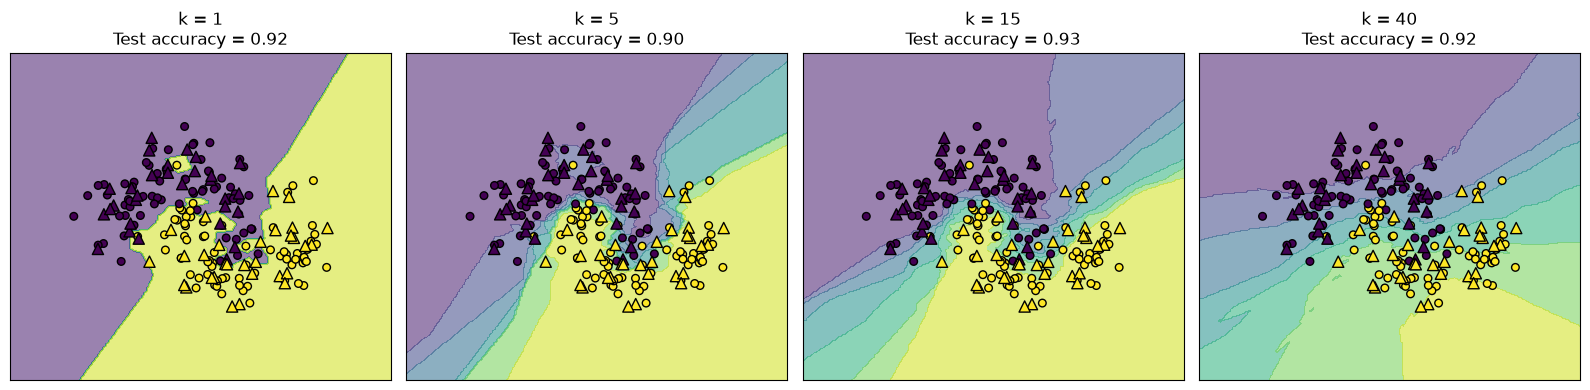

In [10]:
X, y = X_moons, y_moons
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

k_values = [1, 5, 15, 40]
fig, axes = plt.subplots(1, len(k_values), figsize=(16, 4))

for ax, k in zip(axes, k_values):
    model = make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=k))
    model.fit(X_train, y_train)

    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method='predict_proba',
        class_of_interest=1, alpha=0.55,
        grid_resolution=250, ax=ax
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='black', s=30)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='black', s=65, marker='^')
    ax.set_title(f'k = {k}\nTest accuracy = {model.score(X_test, y_test):.2f}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Questions

1. Which value of `k` appears to overfit? - Value of 1 seems to be overfitting as the curve is the most irregular and bent according to the input points.
2. Which value appears to underfit? - Undefit is happened when the value of K is 40 as it considered too many values of k
3. Does the visually most complex boundary always have the highest test accuracy? - No the most complex boundary  is produced when the k is 1 with a test accuracy of 0.92 while the value of K produced smoother boundary and achieving the highest test accuracy of 0.93

## 7. Experiment B: Change tree depth

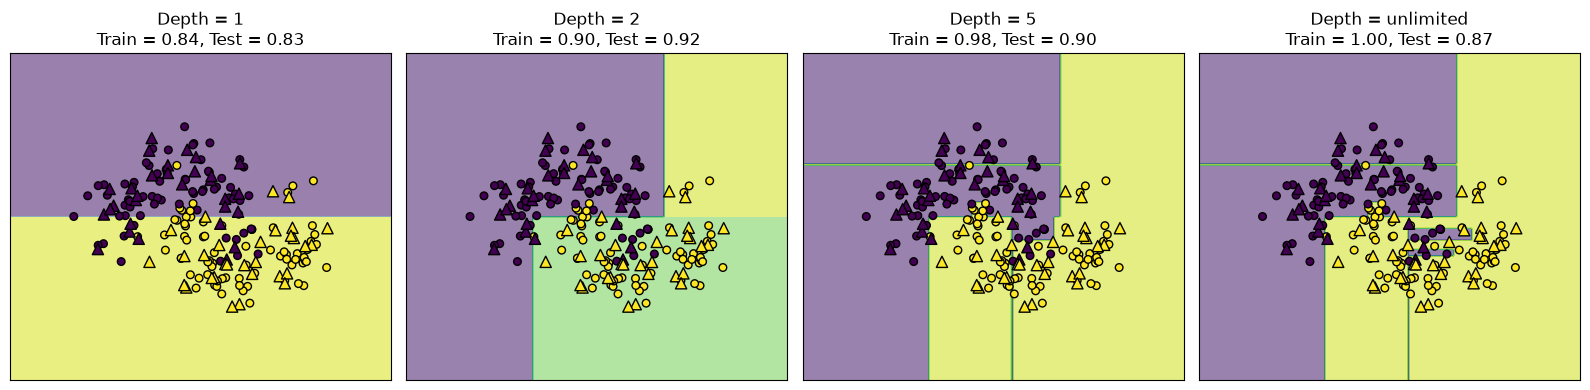

In [11]:
depths = [1, 2, 5, None]
fig, axes = plt.subplots(1, len(depths), figsize=(16, 4))

for ax, depth in zip(axes, depths):
    model = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    model.fit(X_train, y_train)

    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method='predict_proba',
        class_of_interest=1, alpha=0.55,
        grid_resolution=250, ax=ax
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='black', s=30)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='black', s=65, marker='^')
    label = 'unlimited' if depth is None else str(depth)
    ax.set_title(
        f'Depth = {label}\n'
        f'Train = {model.score(X_train, y_train):.2f}, '
        f'Test = {model.score(X_test, y_test):.2f}'
    )
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

### Questions

1. How does increasing depth affect boundary complexity? - Increasing the training depth will increase the number of branches. At depth one we have one boundary whereas with the greater depth there will be more horizontal and vertical boundaries making the boundaries more complex.
2. At what depth does training accuracy become much higher than test accuracy? - Unlimited depth will have more vertical and horizontal boundaries which eventually learns every pattern of the data and produces the training accuracy of 100 percent and it will perform poorly with the test data. It is clearly evident incase of the ulimited depth as the test accuracy is 0.87 which is less the training accuracy of 1. 
3. Why are all decision-tree boundaries horizontal or vertical? - Decision tree splits only one feature at a time. So feature 1 can all in to vertical partition and feature 2 can form into horizontal partition. Source: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html?utm_source=chatgpt.com (Redirected from websearch feature of chatgpt)

## 8. Experiment C: Linear versus nonlinear SVM

The original figure uses a linear SVM. Add an RBF-kernel SVM to see how a nonlinear feature mapping changes the decision boundary.

C:\Users\suras\Documents\csce5218\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\suras\Documents\csce5218\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


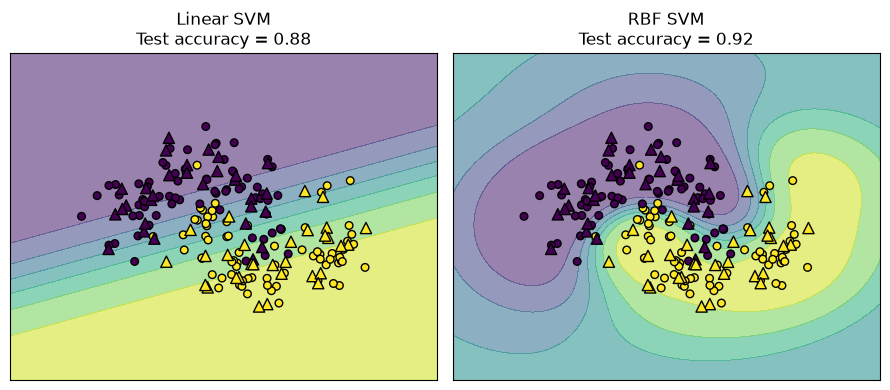

In [12]:
svm_models = [
    ('Linear SVM', make_pipeline(StandardScaler(), SVC(kernel='linear', C=1, probability=True))),
    ('RBF SVM', make_pipeline(StandardScaler(), SVC(kernel='rbf', C=1, gamma='scale', probability=True))),
]

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

for ax, (name, model) in zip(axes, svm_models):
    model.fit(X_train, y_train)
    DecisionBoundaryDisplay.from_estimator(
        model, X, response_method='predict_proba',
        class_of_interest=1, alpha=0.55,
        grid_resolution=250, ax=ax
    )
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='black', s=30)
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='black', s=65, marker='^')
    ax.set_title(f'{name}\nTest accuracy = {model.score(X_test, y_test):.2f}')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel('')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## 9. Optional extension: confusion matrix

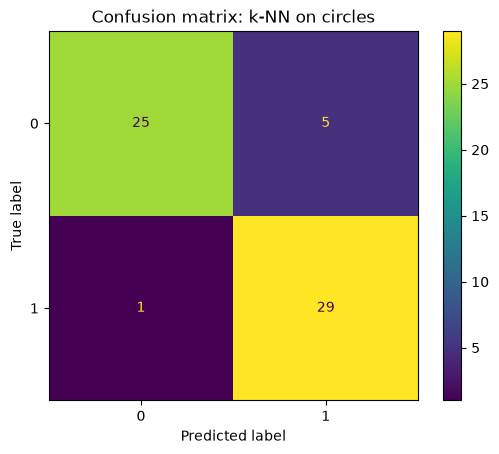

In [13]:
# Choose a dataset and classifier to inspect.
X, y = X_circles, y_circles
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)

model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=7)
)
model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.title('Confusion matrix: k-NN on circles')
plt.show()

## 10. Submission questions

Submit a short response answering these questions:

1. Why does the linear SVM fail on concentric circles? - Linear SVM can only produce a straight decision boundary. Concentric circles cannot be separated with a straight line. RBF SVM can handle this better as it produces nonlinear boundaries.
2. Why does a decision tree create rectangular regions? - Each tree node compared one feature with a threshold. Split on one data point creates a veritical boundary whereas a split on other feature produces a horizontal boundary. Combining both veritical and horizontal boundaries produces rectangular regions.
3. How does increasing `k` change the bias-variance tradeoff of k-NN? - Small k produces a flexible boundary, it may overfit with low bias and high variance. Increasing k smoothens the boundary, and increases bias and reduces the variance. It k becomes too large, it can undefit with large bias and low variance.
4. Give one example of underfitting and one example of overfitting from your experiments. - The linear SVM undefit the circles dataset, because of the low training accuracy of 0.550 and low test accuracy of 0.517. This produces a straight line that cannot represent circular classes. The unlimited decision tree overfit the moons datset, as it achieved the 100 percent training accuracy and 87 percent test accuracy
5. Which classifier would you choose for each dataset, and why?
   1. Moons - I choose K-NN with k value 15, due to the highest test accuracy of 0.93
   2. Circles - Based on the results, I would choose gaussian Naive bayes, because it achieved 0.983 test accuracy. and the gap is also very less (0.048)
   3. Approximately Linear - I would choose naive gaussion bayes again as it is simpler and matched the approximate gaussian class distributions. KNN is also achieved hihgest test accuracy accuracy but due to irregular boundary of knn may not be a good choice.
7. Why should model selection be based on held-out data rather than training accuracy alone? Training accuracy measures performance on data that has already seen, so complex model achived highest training accuracy, but performs poorly with test data. for example in case of unlimited training depth accuracy is highest but performed poorly with the test data.

### Challenge

Create a fourth synthetic dataset and predict, before running the code, which classifier will perform best. Then test your prediction.

# Sine wave boundary

1. As the sine wave is non linear data with a curve, RBF SVM will perform better as this follows the curved path. It will create a smooth nonlinear decision boundary. Knn also can peform better but the boundary may be irregular.

In [14]:
def make_sine_classification(
    n_samples = 250,
    noise=0.20,
    random_state=42
):
    random_ng = np.random.RandomState(random_state)
    X=random_ng.uniform(
        low=[-3, -2],
        high=[3, 2],
        size=(n_samples, 2)
    )

    boundary_noise=random_ng.normal(
        loc=0.0,
        scale=noise,
        size=n_samples
    )

    y = (
        X[:, 1] > np.sin(X[:,0]) + boundary_noise
    ).astype(int)
    return X, y
    

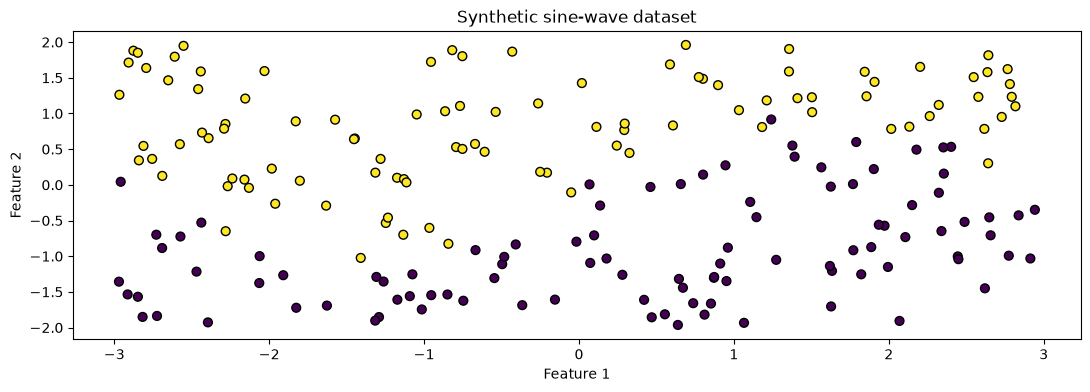

In [20]:
X_sine, y_sine = make_sine_classification(
    n_samples=200,
    noise=0.25,
    random_state=RANDOM_STATE
)

plt.figure(figsize=(13, 4))

plt.scatter(
    X_sine[:, 0],
    X_sine[:, 1],
    c=y_sine,
    edgecolors="black",
    s=40
)


plt.title("Synthetic sine-wave dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

C:\Users\suras\Documents\csce5218\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
C:\Users\suras\Documents\csce5218\venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


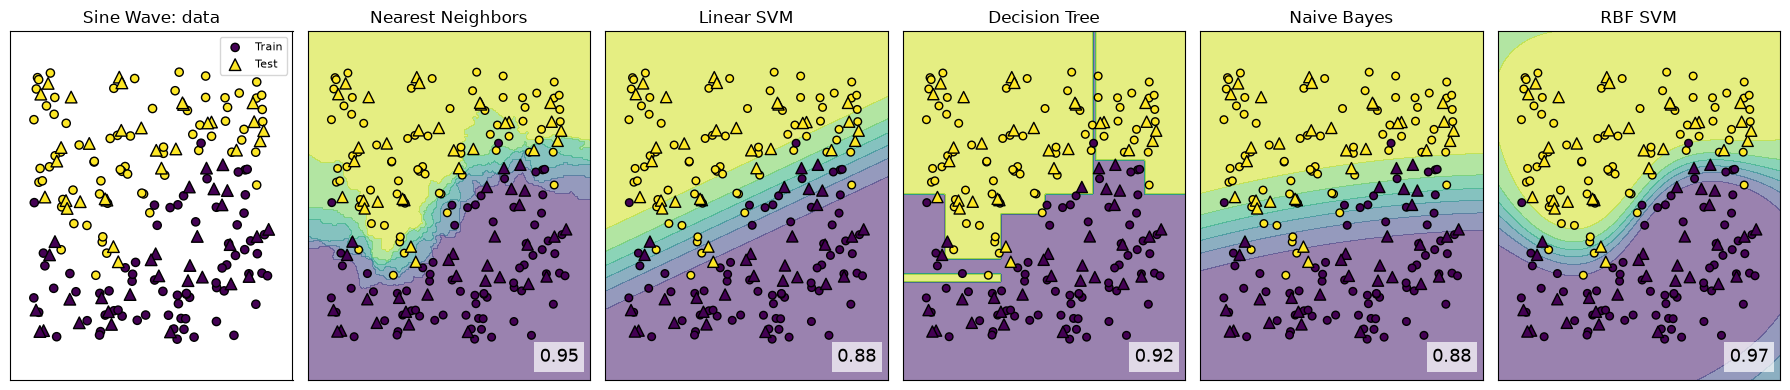

In [24]:
classifiers.append(
    (
        "RBF SVM",
        make_pipeline(
            StandardScaler(),
            SVC(
                kernel="rbf",
                C=1,
                gamma="scale",
                probability=True
            )
        )
    )
)
def plot_classifier_comparison(datasets, classifiers):
    n_rows = len(datasets)
    n_cols = len(classifiers) + 1
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4), squeeze=False)

    for row, (dataset_name, X, y) in enumerate(datasets):
        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.30,
            stratify=y,
            random_state=RANDOM_STATE,
        )

        x_min, x_max = X[:, 0].min() - 0.6, X[:, 0].max() + 0.6
        y_min, y_max = X[:, 1].min() - 0.6, X[:, 1].max() + 0.6

        # First column: raw data
        ax = axes[row, 0]
        ax.scatter(
            X_train[:, 0], X_train[:, 1], c=y_train,
            edgecolors='black', s=35, label='Train'
        )
        ax.scatter(
            X_test[:, 0], X_test[:, 1], c=y_test,
            edgecolors='black', s=70, marker='^', label='Test'
        )
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title(f'{dataset_name}: data')
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.legend(loc='upper right', fontsize=8)

        for col, (model_name, model) in enumerate(classifiers, start=1):
            ax = axes[row, col]
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            score = accuracy_score(y_test, y_pred)

            # probability gives a smooth confidence background
            DecisionBoundaryDisplay.from_estimator(
                model,
                X,
                response_method='predict_proba',
                class_of_interest=1,
                alpha=0.55,
                grid_resolution=250,
                ax=ax,
            )

            ax.scatter(
                X_train[:, 0], X_train[:, 1], c=y_train,
                edgecolors='black', s=30
            )
            ax.scatter(
                X_test[:, 0], X_test[:, 1], c=y_test,
                edgecolors='black', s=65, marker='^'
            )
            ax.set_xlim(x_min, x_max)
            ax.set_ylim(y_min, y_max)
            ax.set_title(model_name)
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_xticks([])
            ax.set_yticks([])
            ax.text(
                0.96, 0.04, f'{score:.2f}',
                transform=ax.transAxes,
                ha='right', va='bottom',
                fontsize=13,
                bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none'},
            )

    plt.tight_layout()
    plt.show()
plot_classifier_comparison( [
    ('Sine Wave', X_sine, y_sine)
], classifiers)

# Summary of the results
I created a synthetic dataset in which points were classified according to whether they were above or below a noisy sine wave boundary. I predicted that the RBF SVM would perform best because it can learn a smooth non-linear boundary. The results supported the prediction, RBF SVM achieved the highest test accuracy of 0.97. k-NN also performed well with 0.95 accuracy, but its boundary is more irregular because it depends on local neighbours. The Decision Tree obtained 0.92 accuracy by approximating the sine curve with horizontal and vertical splits. Linear SVM and Gaussian naive bayes both achieved 0.88 accuracy because their model forms were less suitable for the curved pattern.